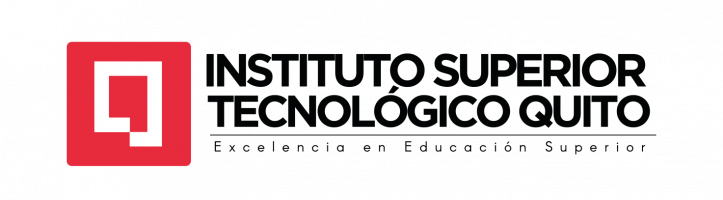

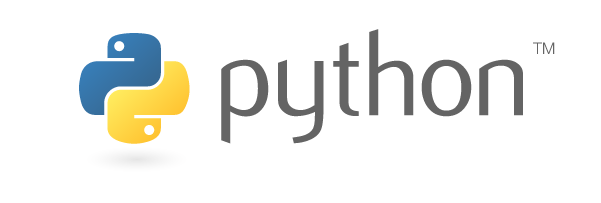

*Byron Armando Melo Aguilar*

*[Enlace a Github](https://github.com/ByronMN911/practicas-machine-learning-I/tree/main/Parcial%20III/Tarea%201)*

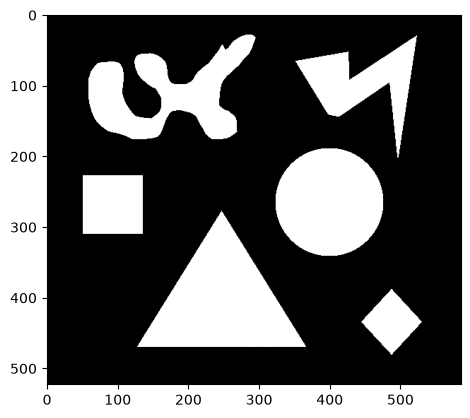

In [1]:
# En primer lugar, obtenemos la máscara de la imagen original mediante la umbralización con Otsu
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Leemos la imagen original
img = cv2.imread('images/figuras.png')

# Convertimos la imagen a escala de grises, ya que Otsu trabaja sobre un único canal de intensidad
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

"""
El método de Otsu calcula automáticamente el umbral óptimo que separa
la imagen en dos clases (fondo y objetos) minimizando la varianza dentro
de cada clase y maximizando la varianza entre clases
Al indicar el flag cv2.THRESH_OTSU, el valor 0 que pasamos como umbral
es ignorado, ya que OpenCV calcula el umbral de forma automática
El valor 1 indica el valor máximo que tomarán los píxeles que superen
dicho umbral
"""
_, mask = cv2.threshold(img_gray,0,1,cv2.THRESH_OTSU)

# Visualizamos la máscara binaria resultante
plt.imshow(mask, cmap='gray')
plt.show()

número de objetos:  6
posibles valores de intensidad:  [0 1 2 3 4 5 6]


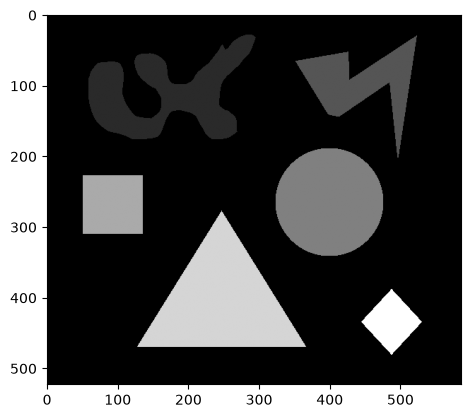

In [2]:
# Convertimos la imagen binaria en una imagen de etiquetas para tener acceso a cada objeto por separado
from skimage.measure import label

"""
La función label recorre la imagen binaria e identifica las regiones
conectadas, asignando un número entero distinto a cada una de ellas
El parámetro return_num=True permite obtener también el número total
de objetos detectados
"""
lab, num = label(mask, return_num=True)

# Importante:
# En 'num' devuelve 6 valores correspondientes a los 6 objetos que hay en la imagen.
# Sin embargo, 'lab' contiene hasta 7 valores diferentes, ya que también tiene en cuenta el fondo de la imagen.
print('número de objetos: ', num)

"""
np.unique nos permite comprobar qué valores de intensidad existen en
la imagen etiquetada y cuántos píxeles corresponden a cada uno
El valor 0 siempre corresponde al fondo, mientras que del 1 en adelante
corresponde a cada uno de los objetos detectados
"""
v,c = np.unique(lab, return_counts=True)
print('posibles valores de intensidad: ', v)

# Visualizamos la imagen etiquetada, donde cada objeto tiene un valor distinto
plt.imshow(lab, cmap='gray')
plt.show()

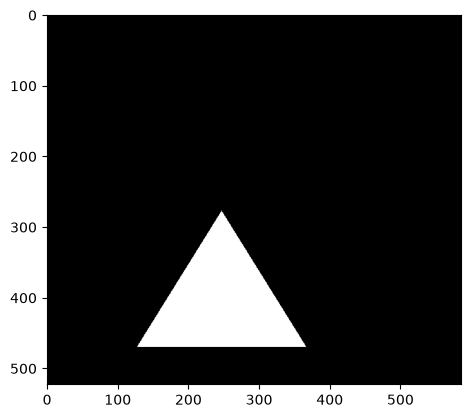

In [19]:
"""
Podemos acceder de manera independiente al objeto que nos interese a partir de su etiqueta correspondiente
Al comparar la imagen de etiquetas con un valor concreto (en este caso 1)
obtenemos una máscara booleana donde solo aparece dicho objeto
"""
objeto = lab == 5

# Convertimos la máscara booleana a uint8 para poder trabajar con ella en OpenCV
objeto = objeto.astype('uint8')

# Visualizamos el objeto aislado
plt.imshow(objeto, cmap='gray')
plt.show()

(277, 128, 470, 367)


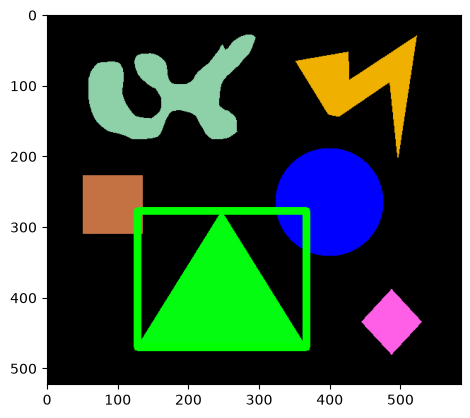

In [20]:
from skimage.measure import regionprops
# https://scikit-image.org/docs/dev/api/skimage.measure.html#skimage.measure.regionprops

"""
regionprops calcula un conjunto de propiedades geométricas para cada
región etiquetada de la imagen (área, perímetro, bounding box, etc)
Al recibir una imagen binaria con un único objeto, la lista devuelta
contendrá una sola posición
"""
# Después, podemos extraer la bounding box de dicho objeto
prop = regionprops(objeto)

"""
bbox devuelve las coordenadas de la caja delimitadora en el formato
(min_row, min_col, max_row, max_col), es decir, fila y columna del
punto superior izquierdo, y fila y columna del punto inferior derecho
"""
bbox = prop[0].bbox
print(bbox)

"""
cv2.rectangle espera las coordenadas en formato (x, y), es decir
(columna, fila), por lo que es necesario invertir el orden respecto
a como los devuelve regionprops
"""
start_point = (bbox[1], bbox[0])
end_point = (bbox[3], bbox[2])

# Dibujamos el rectángulo sobre una copia de la imagen original para no modificarla
window = cv2.rectangle(img.copy(), start_point, end_point, (0, 255, 0), 10)

# Visualizamos el resultado
plt.imshow(window, cmap='gray')
plt.show()

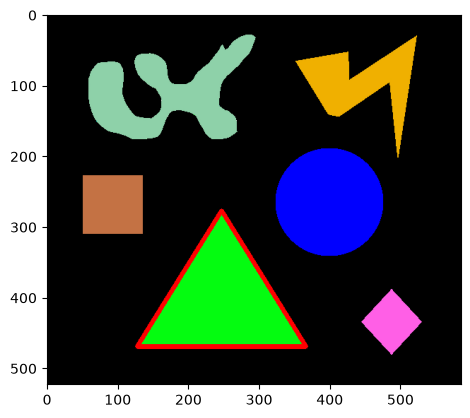

In [21]:
# Y la convex hull image
from skimage.morphology import convex_hull_image

"""
convex_hull_image calcula la envolvente convexa de un objeto, es decir
el polígono convexo más pequeño que contiene por completo la forma
Esto resulta muy útil para obtener el contorno "relleno" de figuras
con concavidades
"""
convex_image = convex_hull_image(objeto)

# Convertimos la imagen booleana resultante a uint8 para poder procesarla con OpenCV
convex_image = convex_image.astype('uint8')

# plt.imshow(convex_image, cmap='gray')
# plt.show()

"""
findContours localiza los contornos presentes en una imagen binaria
RETR_TREE recupera todos los contornos y reconstruye su jerarquía completa
CHAIN_APPROX_SIMPLE comprime los puntos horizontales, verticales y
diagonales, dejando únicamente los puntos extremos necesarios para
representar el contorno, lo que ahorra memoria
"""
conts,_ = cv2.findContours(convex_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE) # Encontramos los contornos en una máscara

# Dibujamos los contornos encontrados sobre una copia de la imagen original, en color rojo
imagen = cv2.drawContours(img.copy(), conts, -1, (255,0,0), 5) # Dibujamos los contornos

# Visualizamos el resultado
plt.imshow(imagen, cmap='gray')
plt.show()

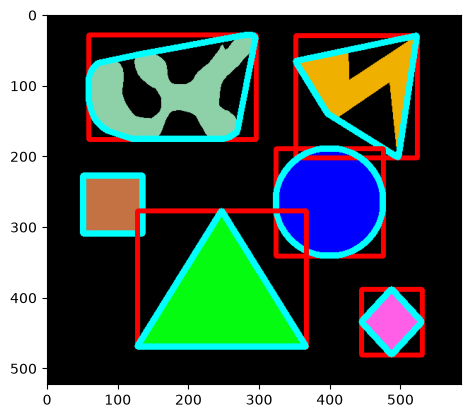

In [23]:
"""
Repetimos el proceso completo para todos los objetos de la imagen
Recorremos cada una de las etiquetas obtenidas anteriormente (de 1 a num)
y para cada una calculamos su bounding box y su convex hull
"""
# Repetimos el proceso completo para todos los objetos de la imagen
imagen = img.copy()

for i in range(1, num+1):
    # Aislamos el objeto correspondiente a la etiqueta actual
    objeto = lab == i
    objeto = objeto.astype('uint8')
    
    # bbox
    # Calculamos las propiedades geométricas del objeto, incluyendo su bounding box
    prop = regionprops(objeto)
    bbox = prop[0].bbox
    # Dibujamos la bounding box en color rojo sobre la imagen acumulada
    imagen = cv2.rectangle(imagen, (bbox[1], bbox[0]), (bbox[3], bbox[2]), (255, 0, 0), 5)
    
    # covex hull
    # Calculamos la envolvente convexa del objeto actual
    convex_image = convex_hull_image(objeto)
    convex_image = convex_image.astype('uint8')
    # Extraemos el contorno de dicha envolvente convexa
    conts,_ = cv2.findContours(convex_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    # Dibujamos el contorno en color amarillo/cian sobre la imagen acumulada
    imagen = cv2.drawContours(imagen, conts, -1, (0,255,255), 8)

# Visualizamos el resultado final con todos los objetos marcados
plt.imshow(imagen, cmap='gray')
plt.show()

In [24]:
"""
Vamos a extraer diferentes descriptores geométricos que nos ayudarán a caracterizar los objetos
Estos descriptores permiten distinguir entre distintos tipos de formas
(círculos, cuadrados, triángulos, etc) de manera cuantitativa, sin
depender únicamente de la inspección visual
"""
# pip install tabulate
from tabulate import tabulate
import math

# Volvemos a etiquetar la máscara para asegurarnos de tener acceso a todos los objetos
new_lab, new_num = label(mask, return_num=True)

# Extraemos las característicias geométricas
"""
Definimos los encabezados de la tabla que mostraremos al final
Cada columna corresponde a una de las figuras presentes en la imagen
"""
headers = ['','Raro', 'Rayo', 'Círculo', 'Cuadrado', 'Triángulo', 'Rombo']

"""
Inicializamos una lista para cada descriptor geométrico
El primer elemento de cada lista es el nombre del descriptor, que
posteriormente se usará como primera columna de la tabla
"""
A,BB,CA,E,ED,EX,MA,MiA,OR,P,S,CO,R = ['area'], ['bbox_area'], ['convex_area'], ['eccentricity'], ['equiv_diameter'], \
['extent'], ['major_axis'], ['minor_axis'], ['orientation'], ['perimeter'], ['solidity'], ['compactness'], ['rectangularity']

for i in range(1,new_num+1):
    # Aislamos el objeto correspondiente a la etiqueta actual
    objeto = new_lab == i
    prop = regionprops(objeto.astype(np.uint8))
    
    # Área total de píxeles del objeto
    A.append(np.round(prop[0].area, 4))
    # Área de la bounding box que contiene al objeto
    BB.append(np.round(prop[0].bbox_area, 4))
    # Área de la envolvente convexa del objeto
    CA.append(np.round(prop[0].convex_area, 4))
    # Excentricidad: mide cuánto se aleja la forma de un círculo perfecto (0 = círculo, cercano a 1 = forma alargada)
    E.append(np.round(prop[0].eccentricity, 4))
    # Diámetro de un círculo que tendría la misma área que el objeto
    ED.append(np.round(prop[0].equivalent_diameter, 4))
    # Extent: relación entre el área del objeto y el área de su bounding box
    EX.append(np.round(prop[0].extent, 4))
    # Longitud del eje mayor de la elipse que mejor se ajusta al objeto
    MA.append(np.round(prop[0].major_axis_length, 4))
    # Longitud del eje menor de dicha elipse
    MiA.append(np.round(prop[0].minor_axis_length, 4))
    # Orientación del eje mayor respecto al eje horizontal
    OR.append(np.round(prop[0].orientation, 4))
    # Perímetro del objeto
    P.append(np.round(prop[0].perimeter, 4))
    # Solidity: relación entre el área del objeto y el área de su envolvente convexa (indica si tiene concavidades)
    S.append(np.round(prop[0].solidity, 4))
    """
    Compactness (compacidad): relaciona el área y el perímetro del objeto
    Cuanto más cercano a 1, más se parece la forma a un círculo perfecto,
    ya que el círculo es la figura con mayor área para un perímetro dado
    """
    CO.append(np.round(4*math.pi*prop[0].area/prop[0].perimeter**2, 4))
    # Rectangularity: relación entre el área del objeto y el área de su bounding box (similar a extent)
    R.append(np.round(prop[0].area/prop[0].bbox_area, 4))

# Agrupamos todos los descriptores en una lista de tuplas, una por cada fila de la tabla
my_data = [tuple(A), tuple(BB), tuple(CA), tuple(E), tuple(ED), tuple(EX), \
           tuple(MA), tuple(MiA), tuple(OR), tuple(P), tuple(S), tuple(CO), tuple(R)]

# Mostramos la tabla final con todos los descriptores geométricos de cada figura
print(tabulate(my_data, headers=headers))

                      Raro        Rayo     Círculo    Cuadrado    Triángulo      Rombo
--------------  ----------  ----------  ----------  ----------  -----------  ---------
area            16198       10282       18344        7055        23119       4018
bbox_area       35076       29756       23104        7055        46127       7998
convex_area     27405       16959       18488        7055        23307       4102
eccentricity        0.8556      0.7941      0           0.2157       0.371      0.3866
equiv_diameter    143.61      114.418     152.828      94.7771     171.569     71.5254
extent              0.4618      0.3455      0.794       1            0.5012     0.5024
major_axis        268.45      186.995     152.828      98.1428     195.774     76.1969
minor_axis        138.975     113.644     152.828      95.8332     181.801     70.2735
orientation        -1.4236      1.5298     -0.7854      1.5708      -1.5708     0
perimeter        1029.77      736.02      503.245     332      

C:\Users\Arman\AppData\Local\Temp\ipykernel_8256\3867806487.py:37: FutureWarning: `RegionProperties.bbox_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_bbox` instead. 
  BB.append(np.round(prop[0].bbox_area, 4))
C:\Users\Arman\AppData\Local\Temp\ipykernel_8256\3867806487.py:39: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  CA.append(np.round(prop[0].convex_area, 4))
C:\Users\Arman\AppData\Local\Temp\ipykernel_8256\3867806487.py:43: FutureWarning: `RegionProperties.equivalent_diameter` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.equivalent_diameter_area` instead. 
  ED.append(np.round(prop[0].equivalent_diameter, 4))
C:\Users\Arman\AppData\Local\Temp\ipykernel_8256\3867806487.py:47: FutureWarning: `RegionProperties.major_axis_length` is deprecated startin